In [1]:
# # IMPORTANT: SOME KAGGLE DATA SOURCES ARE PRIVATE
# # RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES.
# import kagglehub
# kagglehub.login()

In [2]:
# # IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# # THEN FEEL FREE TO DELETE THIS CELL.
# # NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# # ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# # NOTEBOOK.

# stphaneaholoubah_fr_audio_dataset_path = kagglehub.dataset_download('stphaneaholoubah/fr-audio-dataset')

# print('Data source import complete.')

In [3]:
# %%capture 
# !pip install --upgrade transformers mistral-common nemo_toolkit['asr'] qwen-asr evaluate jiwer datasets[audio] librosa soundfile torchcodec torchaudio pandas matplotlib tqdm accelerate bitsandbytes  

In [4]:
%%capture
!pip install evaluate jiwer datasets[audio] librosa soundfile torchcodec

In [5]:
%%capture
!pip install -q torchaudio jiwer librosa soundfile wordcloud umap-learn scikit-learn python-levenshtein pandas matplotlib tqdm accelerate bitsandbytes nemo_toolkit['asr'] qwen-asr

In [6]:
import transformers
print(transformers.__version__)

4.57.6


In [7]:
# %%capture
# !pip install transformers --upgrade --force-reinstall

In [8]:
from pathlib import Path

import os, torch, torchaudio, librosa, soundfile as sf
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm
import json, gc

from datasets import Dataset, Audio
from transformers import AutoProcessor, WhisperProcessor, WhisperForConditionalGeneration #, VoxtralRealtimeForConditionalGeneration
from qwen_asr import Qwen3ASRModel
from nemo.collections.asr.models import ASRModel

from huggingface_hub import snapshot_download

from jiwer import wer, cer
from collections import Counter
# from wordcloud import WordCloud
# from sklearn.metrics.pairwise import cosine_distances
# import umap
# import Levenshtein as Lev

2026-03-04 16:41:51.356557: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1772642511.567383      24 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1772642511.632846      24 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1772642512.132002      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1772642512.132058      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1772642512.132065      24 computation_placer.cc:177] computation placer alr

In [9]:
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
SAMPLE_RATE = 16000
LANG = "fr"
TASK = "transcribe"

torch.backends.cuda.matmul.allow_tf32 = True

In [10]:
def chunk_audio(wav, chunk_size_sec=25, sr=16000):
    chunk_len = chunk_size_sec * sr
    return [wav[i:i+chunk_len] for i in range(0, len(wav), chunk_len)]

In [ ]:
import os
from kaggle_secrets import UserSecretsClient
from huggingface_hub import login

HF_TOKEN = os.getenv("HF_TOKEN")
if not HF_TOKEN:
    try:
        HF_TOKEN = UserSecretsClient().get_secret("HUGGING_FACE_TOKEN")
    except Exception as exc:
        raise ValueError("HF_TOKEN is required via environment or Kaggle secret HUGGING_FACE_TOKEN") from exc

login(token=HF_TOKEN)

In [12]:
path = "/kaggle/input/datasets/stphaneaholoubah/fr-audio-dataset/Collecte_Audio_FR_Radiologie-20260119T004052Z-3-001/Collecte_Audio_FR_Radiologie"

In [13]:
# from google.colab import drive
# drive.mount('/content/drive')
# path = "/content/drive/MyDrive/Collecte_Audio_FR_Radiologie"

In [14]:
# Charger le dictionnaire dico_corpus.json
with open(path + '/dico_corpus.json', 'r') as f:
  dico_corpus = json.load(f)

In [15]:
records = []
for idx, meta in dico_corpus.items():
    try:
        folder = f"{path}/{meta['identifiant']}"
        # parcourir tous les fichiers .wav (ou .mp3) dans le dossier
        for fname in os.listdir(folder):
            if fname.endswith(('.wav', '.flac', '.mp3', '.webm')):
                records.append({
                    "audio": os.path.join(folder, fname),
                    "text": meta['contenu']
                })
    except FileNotFoundError:
        print(f"Dossier introuvable ou vide : {folder}")
    except Exception as e:
        print(f"Erreur inattendue pour {folder} : {e}")

Normalisation de texte

In [16]:
def normalize_text(text):
    text = text.lower()
    text = text.replace('\n', ' ')
    # text = re.sub(r'[^\w\s]', ' ', text)  # Remplacer ponctuation par espace
    # text = re.sub(r'(\d+)', r' \1 ', text)  # Espacer les chiff
    return text

# records = list(map(lambda r: normalize_text(r["text"]), records))
for record in records:
    record['text'] = normalize_text(record['text'])

In [17]:
print(records[0])

{'audio': '/kaggle/input/datasets/stphaneaholoubah/fr-audio-dataset/Collecte_Audio_FR_Radiologie-20260119T004052Z-3-001/Collecte_Audio_FR_Radiologie/report_CnGIjpEu9WIl3lJXeIdIY7Cd-txSUNoMToy_TWma32Y/synth_0_YwEKgPNrswweXodAZi29.mp3', 'text': 'fracture peu déplacée du col huméral.'}


Reservation d'ensemble de test après entraînement

| Fichier audio                                                                                                                    | Catégorie                                                              |
| -------------------------------------------------------------------------------------------------------------------------------- | ---------------------------------------------------------------------- |
|Collecte\_Audio\_FR\_Radiologie/report\_NxSmAyYz42CeH1IRNJXaSVSHMRR\_WJ0IF0bvxM7z2Ak/recorded\_audio.wav  | Colonne cervicale : examen normal                                      |
|Collecte\_Audio\_FR\_Radiologie/report\_oqzb78c\_pgfdiw1j5VE7h2EbK8pDy6JzqpeZG0SBT2Q/recorded\_audio.wav  | Colonne cervicale : discarthrose et uncarthrose                        |
|Collecte\_Audio\_FR\_Radiologie/report\_Kl4hVMi1xNQayscnSkVzc3xVrE7s88OdydZqFsf5CMM/recorded\_audio.wav   | Colonne lombaire : discarthrose + scoliose + antélisthésis             |
|Collecte\_Audio\_FR\_Radiologie/report\_aOw5Iu1dR7gITUx4qsYWzVqkf8z1FaHIvXKc4vZS2LA/recorded\_audio.wav   | Colonne lombaire : discopathie L3–S1                                   |
|Collecte\_Audio\_FR\_Radiologie/report\_KXz0PIoW4XbD-b2l7CESbvRebk3l57NMa5-hcUrl6Co/recorded\_audio.wav   | Colonne dorsale/lombaire : tassement vertébral T12 + discopathie L4–L5 |
|Collecte\_Audio\_FR\_Radiologie/report\_2TnSIhg-drDPZ2eu54sk6Rj36XSSUxm\_NqpZKI7BYyg/recorded\_audio.wav  | Colonne cervicale : raideur avec lordose effacée                       |
|Collecte\_Audio\_FR\_Radiologie/report\_8BAs0TZXB8Ws9zn7KBV93ppcUo5CuywO\_FzNxSfxXNs/recorded\_audio.wav  | Colonne lombaire : discarthrose débutante L2–L4                        |
|Collecte\_Audio\_FR\_Radiologie/report\_9OugJTY\_WxUoOJ33vQwAYsol4zHP\_dcjAURHmHGKPfA/recorded\_audio.wav | Épaule : fracture du col de l’humérus                                  |
|Collecte\_Audio\_FR\_Radiologie/report\_QxjI35WATxkcOthJzYrmpFFdVz7Etu70eKJ-WuYocSk/recorded\_audio.wav   | Épaule : disjonction acromio‑claviculaire                              |
|Collecte\_Audio\_FR\_Radiologie/report\_cWaGlBdGxIHIyIPD1Ac8iJ4fc9tRT1tVEfYKQwbo0ys/recorded\_audio.wav   | Épaule : luxation gléno‑humérale antéro‑interne                        |
|Collecte\_Audio\_FR\_Radiologie/report\_k1S-S-2HekY8y8o-\_hNrQvTmYvezomCCJyD7S5\_Qn2g/recorded\_audio.wav | Épaule : arthrose acromio‑claviculaire bilatérale                      |
|Collecte\_Audio\_FR\_Radiologie/report\_ohuSPicvcj6wDc064GnEXhdkQW4Z9vJCTq5ItHnkyqM/recorded\_audio.wav   | Épaule : fracture de la scapula + disjonction acromio‑claviculaire     |
|Collecte\_Audio\_FR\_Radiologie/report\_mammographie\_140/recorded\_audio.wav                             | Mammographie : seins type C, examen ACR0 (normal)                      |
|Collecte\_Audio\_FR\_Radiologie/report\_mammographie\_148/recorded\_audio.wav                             | Mammographie : seins type B avec kyste (seins droit ACR2)              |
|Collecte\_Audio\_FR\_Radiologie/report\_yP4Wtno91JVex6cd4izFsQ06267flev6YdydB8rjebI/recorded\_audio.wav   | Thorax : pneumopathie bilatérale à prédominance droite                 |
|Collecte\_Audio\_FR\_Radiologie/report\_rst1Vqx2nrf-r0U51UuevbXdLwxDnhKnjmYjXJAk1ww/recorded\_audio.wav   | Extrémité : fracture de la phalange distale de l’hallux                |
|Collecte\_Audio\_FR\_Radiologie/report\_WPaxdNrHQGE14sctuPQ4DOFp\_wb8vtgP5StxXZJ37Hg/recorded\_audio.wav  | Tête : otomastoïdite gauche (rocher gauche)                            |


In [18]:
test_audios = [
    # === 17 AUDIOS DÉJÀ ISOLÉS ===
    "/report_NxSmAyYz42CeH1IRNJXaSVSHMRR_WJ0IF0bvxM7z2Ak/recorded_audio.wav",
    "/report_oqzb78c_pgfdiw1j5VE7h2EbK8pDy6JzqpeZG0SBT2Q/recorded_audio.wav",
    "/report_Kl4hVMi1xNQayscnSkVzc3xVrE7s88OdydZqFsf5CMM/recorded_audio.wav",
    "/report_aOw5Iu1dR7gITUx4qsYWzVqkf8z1FaHIvXKc4vZS2LA/recorded_audio.wav",
    "/report_KXz0PIoW4XbD-b2l7CESbvRebk3l57NMa5-hcUrl6Co/recorded_audio.wav",
    "/report_2TnSIhg-drDPZ2eu54sk6Rj36XSSUxm_NqpZKI7BYyg/recorded_audio.wav",
    "/report_8BAs0TZXB8Ws9zn7KBV93ppcUo5CuywO_FzNxSfxXNs/recorded_audio.wav",
    "/report_9OugJTY_WxUoOJ33vQwAYsol4zHP_dcjAURHmHGKPfA/recorded_audio.wav",
    "/report_QxjI35WATxkcOthJzYrmpFFdVz7Etu70eKJ-WuYocSk/recorded_audio.wav",
    "/report_cWaGlBdGxIHIyIPD1Ac8iJ4fc9tRT1tVEfYKQwbo0ys/recorded_audio.wav",
    "/report_k1S-S-2HekY8y8o-_hNrQvTmYvezomCCJyD7S5_Qn2g/recorded_audio.wav",
    "/report_ohuSPicvcj6wDc064GnEXhdkQW4Z9vJCTq5ItHnkyqM/recorded_audio.wav",
    "/report_mammographie_140/recorded_audio.wav",
    "/report_mammographie_148/recorded_audio.wav",
    "/report_yP4Wtno91JVex6cd4izFsQ06267flev6YdydB8rjebI/recorded_audio.wav",
    "/report_rst1Vqx2nrf-r0U51UuevbXdLwxDnhKnjmYjXJAk1ww/recorded_audio.wav",
    "/report_WPaxdNrHQGE14sctuPQ4DOFp_wb8vtgP5StxXZJ37Hg/recorded_audio.wav",

    # === - AUDIOS SUPPLÉMENTAIRES (STRATÉGIQUEMENT SÉLECTIONNÉS) ===
    # Rachis cervical - enregistrements réels variés
    "/report_-O1r169VFVEEU1dE_V7k796-gHSrejx7vP31B3xjwGQ/recorded_audio.wav",
    "/report_25hGADGBJ-9JShEtUkve_-tQuPM5YXMrpvIbGUUeMnw/recorded_audio.wav",

    # Rachis lombaire - enregistrements réels variés
    "/report_-Vp1H5PA4aRWlyUun4-_BF7ulOIaQts33AyLx4u99ZY/recorded_audio.wav",
    "/report_CLhHrHn6gUnH_Y85jwkBxTdLV8l988kP4t8dqX88EOM/recorded_audio.wav",
    "/report_5l4qa9ZXxUjtJhjX6aJlYVX4Uyk84V6OxXk4OcE-eBw/recorded_audio.wav",
    "/report_Aw83VqsjTaJPqmJs3V8K62TKdPGf2teimaAraLbUYvk/recorded_audio.wav",
    "/report_LTGcgYQHn3jodezHEcaL4U875_D9lw5uyVj80wJDS-Q/recorded_audio.wav",
    "/report__Y3tcI0v4TGqvFnJi3RR6EIgXZAAqPV_2okj-O_tHpA/recorded_audio.wav",
    "/report_J40fR_huk0Q3eF9dY0CEmu9L4Arf5Brg7zZ_6wZvd4E/recorded_audio.wav",

    # Épaule - enregistrements réels variés
    "/report_AvbwWOhHa-4Sc3507QwvwCEl402LfskBhScNvStIwbg/recorded_audio.wav",
    "/report_Frb_V-7-kZmFpmEz39AT8zAkdBEjFEdSciY8SE6_e7w/recorded_audio.wav",
    "/report_znO7zb_1ESS_RL7NlkmnkdylTIvg5SSzSjaDTzZPzKw/recorded_audio.wav",
    "/report_FL6K0Brxi0Ml0GGNplbgRA80x68RAhMtszHSbEMf-lQ/recorded_audio.wav",
    "/report_V67AdLVnpX8i9WEsE6BY4-InmLGWhDqTeYIFQx_eZM4/recorded_audio.wav",
    "/report_U3fjfSYQ5YuxfbU_utlKPy0EjiA1AjBEDI2itIRyFyU/recorded_audio.wav",
    "/report_fdmMA3E8aDoDr0RTFTxNu6RlH9SrwNEyif3Wix0flK0/recorded_audio.wav",

    # Thorax/Côtes - enregistrements réels
    "/report_58h1nB0MUCet2VQogEjD6__b9R-PXPedeQPEI9GsEdo/recorded_audio.wav",
    "/report_dazq4xPq_LhPnz2bgyQmYHcKrXx3yNo5auG2swnSmpU/recorded_audio.wav",
    "/report_KqDWw6GF2UHml2c59jAD5n3HLL30iKBAE3j_4f0uTWg/recorded_audio.wav",
    "/report_LxbmrrVRwIASQa_lfBOosw7VZ3SCh6LjtDErc2fOcPs/recorded_audio.wav",
    "/report_s9CD2920VYRGv7duFpImuQ-nxavisGmWGVo0gQ9zfe4/recorded_audio.wav",

    # Fractures diverses - enregistrements réels
    "/report_kR-6UhzsPBjFscqHQP_B34dPsbqtd0jI6ZINZA8Ien4/recorded_audio.wav",
    "/report_CnGIjpEu9WIl3lJXeIdIY7Cd-txSUNoMToy_TWma32Y/recorded_audio.wav",
    "/report_Hciy9mOCW3c9hQCzshDT5pxl5ZgeZ87adV6VpAm8TPc/recorded_audio.wav",

    # Mammographie - enregistrements réels
    "/report_mammographie_121/recorded_audio.wav",
    "/report_mammographie_138/recorded_audio.wav",
    "/report_mammographie_155/recorded_audio.wav",

    # TDM/Examens complexes
    "/report_uU9gmaeXw_oVVi7Bwo0eJ2Cu_pppkKU-FQ1nc38p470/recorded_audio.wav",

    # Autres examens variés
    "/report__gqmZnO9sp0ZzFWzH371jWQBL_R6xD91E-Lx1IfJ7-Q/recorded_audio.wav",
    "/report_qZpQYdL_fpYFbUfYbZoh9sR8xjDxgoxwM2XuLNfyl8g/recorded_audio.wav",

    # === AUDIOS SYNTHÉTIQUES (pour diversité des voix) ===
    # Voix synthétique 4SFJvuIUvxaPLgk8FoK3 (SPEAKER_23)
    "/report_0Jn2RPfGj_STL7GdrNX7W1-C4-p3rPUjgqZqDD5HgF0/synth_64_4SFJvuIUvxaPLgk8FoK3.mp3",
    "/report_43OifUVMfXwbq397L6I5RIU5knG-m4o0ifC1d4YWtSw/synth_62_4SFJvuIUvxaPLgk8FoK3.mp3",
    "/report_1urL6qQEO-EV2WdsWQ96t8bdd2m8_o8YjN_a0FScaQQ/synth_59_4SFJvuIUvxaPLgk8FoK3.mp3",
    "/report_883DnaoG7JMvagtWymk-_V2YtKJ7Yy5ADA0aviaQB_8/synth_105_4SFJvuIUvxaPLgk8FoK3.mp3",
    "/report_Y8bKZcL78ICsat9Br20mA7p69QQNGFaHgfIY8_N6MVI/synth_106_4SFJvuIUvxaPLgk8FoK3.mp3",

    # Voix synthétique mQS95w8LbLFsF6QihxDH (SPEAKER_32)
    "/report_-Vp1H5PA4aRWlyUun4-_BF7ulOIaQts33AyLx4u99ZY/synth_87_mQS95w8LbLFsF6QihxDH.mp3",
    "/report_25hGADGBJ-9JShEtUkve_-tQuPM5YXMrpvIbGUUeMnw/synth_78_mQS95w8LbLFsF6QihxDH.mp3",
    "/report_43OifUVMfXwbq397L6I5RIU5knG-m4o0ifC1d4YWtSw/synth_62_mQS95w8LbLFsF6QihxDH.mp3",

    # Voix synthétique FgHDn7bpgpKqz7QttoyC (SPEAKER_36)
    "/report_2TnSIhg-drDPZ2eu54sk6Rj36XSSUxm_NqpZKI7BYyg/synth_145_FgHDn7bpgpKqz7QttoyC.mp3",
    "/report_CfcGA_MYB8L1r5SsyerahlNPN72EUbe6HFy-hQzTK5g/synth_121_FgHDn7bpgpKqz7QttoyC.mp3",
    "/report_GkxZ8fczykCkgCCDNkQ3iSXA12lHZmzfBzhagp_OdVg/synth_117_FgHDn7bpgpKqz7QttoyC.mp3",

    # Voix synthétique 6aRkp7Pz4MBOSpUyJCTO (SPEAKER_31)
    "/report_0Jn2RPfGj_STL7GdrNX7W1-C4-p3rPUjgqZqDD5HgF0/synth_64_6aRkp7Pz4MBOSpUyJCTO.mp3",
    "/report_4epGcPG2Wva5Ez2FYaY5qTMVEgwRJCfo6cmHsphqj6s/synth_48_6aRkp7Pz4MBOSpUyJCTO.mp3",
    "/report_6rHb7QWe7u0CS_hHNAPaL8QTX7O0WQXbw7q-IF1-vMg/synth_60_6aRkp7Pz4MBOSpUyJCTO.mp3",
    "/report_7Gwzxi03TtV5kb9Je22o4A-mrMEiMEJQEWvXLxg2ur4/synth_42_6aRkp7Pz4MBOSpUyJCTO.mp3",

    # Voix synthétique YwEKgPNrswweXodAZi29 (SPEAKER_37)
    "/report_0q_8Gc9auXyxeX6KC7EoX5KJx3z0vJuvCQYVN2s4JTQ/synth_23_YwEKgPNrswweXodAZi29.mp3",
    "/report_4epGcPG2Wva5Ez2FYaY5qTMVEgwRJCfo6cmHsphqj6s/synth_48_YwEKgPNrswweXodAZi29.mp3",
    "/report_5uAjLRWBJhizfGPRPlgbkZsRIH5K-CF1OO0mWl1yEmk/synth_29_YwEKgPNrswweXodAZi29.mp3",
    "/report_CLhHrHn6gUnH_Y85jwkBxTdLV8l988kP4t8dqX88EOM/synth_31_YwEKgPNrswweXodAZi29.mp3",

    # Voix synthétique Ix5oBMHpatfp3naMIpLk (SPEAKER_33)
    "/report_2TnSIhg-drDPZ2eu54sk6Rj36XSSUxm_NqpZKI7BYyg/synth_145_Ix5oBMHpatfp3naMIpLk.mp3",
    "/report_5l4qa9ZXxUjtJhjX6aJlYVX4Uyk84V6OxXk4OcE-eBw/synth_143_Ix5oBMHpatfp3naMIpLk.mp3",
    "/report_TNy7Z2CZXOi_yptA530ZJplGEARTl1yGktATxOvqVFM/synth_111_Ix5oBMHpatfp3naMIpLk.mp3",

    # Voix synthétique NZ8KtusXpnktPYja5Qko (SPEAKER_38)
    "/report_0q_8Gc9auXyxeX6KC7EoX5KJx3z0vJuvCQYVN2s4JTQ/synth_23_NZ8KtusXpnktPYja5Qko.mp3",
    "/report_58h1nB0MUCet2VQogEjD6__b9R-PXPedeQPEI9GsEdo/synth_36_NZ8KtusXpnktPYja5Qko.mp3",
    "/report_DtJ3ND4F6oWaiJypWwXgGjVYsW9yIHu9cuA5Pe5ewKM/synth_22_NZ8KtusXpnktPYja5Qko.mp3",

    # Voix synthétique K9pQ2PZvpZ94bZfl25YD (SPEAKER_05)
    "/report_FL6K0Brxi0Ml0GGNplbgRA80x68RAhMtszHSbEMf-lQ/synth_10_K9pQ2PZvpZ94bZfl25YD.mp3",
    "/report_M2wTsvq9juqnynWwUSQ3kUhwVruOZzey5faZUfAyuG4/synth_14_K9pQ2PZvpZ94bZfl25YD.mp3",
    "/report_hVxc0Jn2egBrXkz4VN0KXrghVtq0w5VGiCxVWsM2AuI/synth_13_K9pQ2PZvpZ94bZfl25YD.mp3"
]

# Vérification : 75 audios exactement
print(f"Nombre total d'audios sélectionnés : {len(test_audios)}")
print(f"Audios uniques : {len(set(test_audios))}")


Nombre total d'audios sélectionnés : 75
Audios uniques : 75


In [19]:
# fold_path = "/kaggle/input/fr-audio-dataset/Collecte_Audio_FR_Radiologie2/Collecte_Audio_FR_Radiologie"
# eval_audios = [fold_path + r_path for r_path in eval_audios]
test_audios = [path + r_path for r_path in test_audios]

In [20]:
# Create a set of audio paths for the test set
test_audio_paths = set(test_audios)

# Create a new list for test records
test_records = [record for record in records if record["audio"] in test_audio_paths]

# Filter the original records list to remove the test records
records = [record for record in records if record["audio"] not in test_audio_paths]

Création du dataset

In [21]:
# Créer le dataset à partir de la liste
#ds = Dataset.from_list(records)
test_ds = Dataset.from_list(test_records)
# Indiquer que la colonne "audio" contient des fichiers audio
#ds = ds.cast_column("audio", Audio(sampling_rate=16_000))

In [22]:
def load_audio_mono_16k(path: str):
    wav, sr = torchaudio.load(path)                   # gère wav/mp3/flac (selon backend)
    if wav.dim() == 2:
        wav = wav.mean(dim=0)                         # -> mono
    if sr != SAMPLE_RATE:
        wav = torchaudio.functional.resample(wav, sr, SAMPLE_RATE)
    return wav.numpy()

## Listes de termes médicaux choisis pour l'évaluation

In [23]:
# medical_words = ["vertébral", "vertébraux","para‑vertébrales","tassement","postérieur","minéralisation","vertébrale","pincement","ostéophytes",
#                  "inter‑vertébral","fracture","ostéophyte","corporéaux","acromio‑claviculaire","gléno‑humérale","inter‑vertébraux","péri‑articulaires",
#                  "symétriques","cervical","déminéralisation","calcifiante","rotateurs","tendinopathie","antélisthésis","convexité","distorsion","nodulaire",
#                  "scoliose","asymétrie","cervicale","focalisée","axillaire","cranio‑caudale","médio‑latérale‑oblique","palpation","tissulaire","écoulement",
#                  "calcique","discopathie","gynécologique","uncarthrose","antérieur","clavicule","disjonction","déhiscence","intracrânien","pulmonaire",
#                  "bilatérale","conjugaison","ostéocondensation","costo‑diaphragmatiques","foraminal","micro‑calcification","rétrécissement","épanchement",
#                  "comblement","déviation","intraveineuse","rétro‑aréolaire","thoracique","échographie","adénomégalie","arthrose","cartilages","discal",
#                  "enthesopathie","fémoro‑tibial","gonarthrose","rachidienne","semi‑circulaires","tympanique","ossiculaire","mastoïdienne","procidence",
#                  "otomastoidite","cochlée","jugulaire","pneumothorax","pneumopathie","parenchyme","médiastin","pneumatisation","mastoïdiennes","tympanique",
#                  "alvéolaire","atélectasie","biliaires","bronchogramme","centimétrique","coxo‑fémorale"
#                  ]


## Chargement Modèles

In [24]:
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
SAMPLE_RATE = 16000

# === LES MODELES ===
MODELS = {
    # "small_base": "openai/whisper-small", # modele baseline utilisé pour le fine-tuning
    # "small_rad1.1": "StephaneBah/whisper-small-rad-fr1.1", # Encodeur gelé et full fine tuning du Decodeur
    # "small_rad1.2FullFT": "StephaneBah/whisper-small-rad-fr1.2F", # Fine tuning complet(encodeur + decodeur) sans rien gelé
    # "small_rad_lora": "StephaneBah/whisper-small-rad-fr2", # Fine tuning complet en se basant sur LoRA avec QKVO et FFN=False
    # "small_rad_lora2": "StephaneBah/whisper-small-rad-fr3", # Fine tuning complet en se basant sur LoRA avec QKV et FFN=True

    # "small_rad2.0": "StephaneBah/whisper-small-rad-fr2.0", # Fine tuning des 4 premières couches de l'encodeur en partant du "small_rad1.1"(c'était le
    # # meilleur modèle issue de notre première selection, les 2.0 sont de la deuxième) déjà fine tuné sur le decodeur. Donc Décodeur gelé pendant l'opération
    # "small_rad2.0_lora_VO_FFN": "StephaneBah/whisper-small-rad-fr2.0_lora", # même approche mais avec LoRA (VO & FFN=True)
    # "small_rad2.O_lora_QKVO_FFN": "StephaneBah/whisper-small-rad-fr2.0_lora2", # même approche mais avec LoRA (QKVO & FFN=True)

    # "whisper-small-rad-FR1": "StephaneBah/whisper-small-rad-FR1", # Fine Tuning du Decoder avec LoRA from whisper-small
    "whisper-small-rad-FR": ("StephaneBah/whisper-small-rad-FR2", "bc89ed0b5355d02133cdfa02ff3fbdf33128c0e7"), # Fine Tuning des 4 premières couches de l'encoder from whisper-small_rad-FR1
    #"whisper-small-rad-FR3": "StephaneBah/whisper-small-rad-FR3", # Fine-Tuning de l'Encoder(4 premières couches) uniquement from whisper-small
    #"whisper-small-rad-FR4": "StephaneBah/whisper-small-rad-FR4_Combo", # les deux approches simultanément
    #"Whisper-AfroRad-FR":("StephaneBah/Whisper-AfroRad-FR", "bbf397e8feddd34441a209e1bd93a4a32486f7b6"), # best model step 600
    "Whisper-AfroRad-FR":("StephaneBah/Whisper-AfroRad-FR", "574cb8a500851c1b3aade0d79db4a92499c6f5b3"), # best model step 900
    "Med-Whisper-AfroRad-FR":"StephaneBah/Med-Whisper-AfroRad-FR",
    "openai/whisper-small": "openai/whisper-small", # modele baseline utilisé pour le fine-tuning
    #"sanchit-gandhi/whisper-small-fr-1k-steps": "sanchit-gandhi/whisper-small-fr-1k-steps",
    "whisper-small-cv11-french": "bofenghuang/whisper-small-cv11-french",
    #"mozilla-ai/whisper-small-fr": "mozilla-ai/whisper-small-fr",
    #"leduckhai/MultiMed-ST/whisper-small-french": {'repo_id': 'leduckhai/MultiMed-ST', 'subfolder_path': 'asr/whisper-small-french/checkpoint'},
    "openai/whisper-large-v3": "openai/whisper-large-v3",
    "nvidia/canary-1b-v2": "nvidia/canary-1b-v2",
    "Qwen/Qwen3-ASR-0.6B":"Qwen/Qwen3-ASR-0.6B",
    #"mistralai/Voxtral-Mini-4B": "mistralai/Voxtral-Mini-4B-Realtime-2602",
    #"linagora/linto_stt_fr_fastconformer": "linagora/linto_stt_fr_fastconformer"

}


# === PROCESSOR commun ===
LANG = "fr"
TASK = "transcribe"
processor = WhisperProcessor.from_pretrained("openai/whisper-small", language=LANG, task=TASK)
forced_ids = processor.get_decoder_prompt_ids(language=LANG, task=TASK)

# from transformers import pipeline

preprocessor_config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

normalizer.json: 0.00B [00:00, ?B/s]

added_tokens.json: 0.00B [00:00, ?B/s]

special_tokens_map.json: 0.00B [00:00, ?B/s]

##Analyse de Representations

In [25]:
def parse_model_id(model_id):
    """
    Retourne:
    - model_name
    - revision (ou None)
    - model_type
    """

    if isinstance(model_id, str):
        return model_id, None

    elif isinstance(model_id, tuple):
        model_name, revision = model_id
        return model_name, revision

    elif isinstance(model_id, dict):
        return model_id.get("repo_id"), None

    else:
        raise ValueError("Format modèle non supporté")

In [26]:
def load_model_dispatch(model_id):

    model_name, revision = parse_model_id(model_id)

    # ================= WHISPER =================
    if "whisper" in model_name.lower():
        global processor # Declare intent to modify global processor
        global forced_ids # Declare intent to modify global forced_ids

        # Store backups for processor and forced_ids if they are to be temporarily changed for a specific model
        global_processor_backup = None
        global_forced_ids_backup = None
        model_processor_loaded = False # Flag to indicate if a model-specific processor was loaded

        if isinstance(model_id, dict):
            repo_id = model_id['repo_id']
            subfolder_path = model_id['subfolder_path']
            local_dir = snapshot_download(repo_id=repo_id, allow_patterns="asr/whisper-small-french/*", local_dir_use_symlinks=False, revision=None)
            model_path = os.path.join(local_dir, subfolder_path)
            model = AutoModelForSpeechSeq2Seq.from_pretrained(model_path).to(DEVICE).eval()

            try:
                # Backup current global processor and forced_ids before potentially changing them
                global_processor_backup = processor
                global_forced_ids_backup = forced_ids

                model_processor = AutoProcessor.from_pretrained(model_path)
                processor = model_processor  # Assign model-specific processor to global
                forced_ids = processor.get_decoder_prompt_ids(language=LANG, task=TASK) # Update forced_ids for new processor
                model_processor_loaded = True
            except Exception as e:
                print(f"Warning: Could not load AutoProcessor from {model_path}. Using global WhisperProcessor. Error: {e}")

        elif isinstance(model_id, tuple):
            model_name, revision = model_id
            model = WhisperForConditionalGeneration.from_pretrained(model_name, revision=revision).to(DEVICE).eval()

        elif "whisper-large-v3" in model_name.lower():
            # global processor

            # Charger le modèle V3 turbo
            model = WhisperForConditionalGeneration.from_pretrained(model_name).to(DEVICE).eval()

            # Charger le processor spécifique pour V3
            processor = WhisperProcessor.from_pretrained(model_name)  # V3 a processor intégré
            # Remarque: V3 gère le langage et la tâche automatiquement via processor

        else:
            model = WhisperForConditionalGeneration.from_pretrained(model_id).to(DEVICE).eval()

        # Set Whisper timestamp configuration attributes for all models
        if hasattr(processor.tokenizer, 'no_timestamps_token_id'):
            model.config.no_timestamps_token_id = processor.tokenizer.no_timestamps_token_id
            model.generation_config.no_timestamps_token_id = processor.tokenizer.no_timestamps_token_id
        if hasattr(processor.tokenizer, 'begin_timestamps_token_id'):
            model.config.begin_timestamps_token_id = processor.tokenizer.begin_timestamps_token_id
            model.generation_config.begin_timestamps_token_id = processor.tokenizer.begin_timestamps_token_id

        model.generation_config.forced_decoder_ids = forced_ids
        preds, refs, audios = [], [], []


        def transcribe_fn(audio_path):
            wav = load_audio_mono_16k(audio_path)

            inputs = processor(
                wav,
                sampling_rate=SAMPLE_RATE,
                return_tensors="pt"
            ).to(DEVICE)

            with torch.no_grad():
                out = model.generate(
                    **inputs,
                    max_new_tokens=440
                )

            return processor.batch_decode(out, skip_special_tokens=True)[0]

        return model, transcribe_fn


    # ================= QWEN =================
    elif "qwen" in model_name.lower():

        model = Qwen3ASRModel.from_pretrained(
            model_name,
            revision=revision,
            dtype=torch.float16 if torch.cuda.is_available() else torch.float32,
            device_map="cuda:0" if torch.cuda.is_available() else "cpu",
            max_new_tokens=512,
            max_inference_batch_size=8
        )

        def transcribe_fn(audio_path):
            result = model.transcribe(
                audio=audio_path,
                language="French"
            )
            return result[0].text

        return model, transcribe_fn


    # ================= CANARY =================
    elif "canary" in model_name.lower():

        model = ASRModel.from_pretrained(
            model_name=model_name,
            map_location=DEVICE
        )

        def transcribe_fn(audio_path):
            output = model.transcribe(
                [audio_path],
                source_lang="fr",
                target_lang="fr"
            )
            return output[0].text

        return model, transcribe_fn
    # ================= VOXTRAL =================    
    elif "voxtral" in model_name.lower():
        from mistral_common.tokens.tokenizers.audio import Audio
        processor = AutoProcessor.from_pretrained(model_name)
        model = VoxtralRealtimeForConditionalGeneration.from_pretrained(
            model_name, 
            device_map="auto"
        )
    
        def transcribe_fn(audio_path):
            audio = Audio.from_file(audio_path, strict=False)
            audio.resample(processor.feature_extractor.sampling_rate)
            inputs = processor(
                audio.audio_array,
                return_tensors="pt")
            inputs = inputs.to(model.device, dtype=model.dtype)
            with torch.no_grad():
                outputs = model.generate(**inputs, max_new_tokens=512)
                decoded = processor.batch_decode(outputs, skip_special_tokens=True)
            return decoded[0]
            
        return model, transcribe_fn

    else:
        raise ValueError(f"Modèle non supporté: {model_name}")

In [27]:
import os
from huggingface_hub import snapshot_download
from transformers import AutoModelForSpeechSeq2Seq, WhisperProcessor, WhisperForConditionalGeneration

# # Restore global processor and forced_ids if they were temporarily changed
# if model_processor_loaded:
#     processor = global_processor_backup
#     forced_ids = global_forced_ids_backup
@torch.no_grad()
def transcribe_dataset(model_id, ds: Dataset, max_new_tokens=444):

    model, transcribe_fn = load_model_dispatch(model_id)

    preds, refs, audios = [], [], []

    for r in tqdm(ds, desc=f"Transcribe: {model_id}"):

        try:
            hyp = transcribe_fn(r["audio"])
        except Exception as e:
            print(f"❌ Erreur sur {r['audio']} → {e}")
            continue

        preds.append(hyp)
        refs.append(r["text"])
        audios.append(r["audio"])

    # Nettoyage mémoire sérieux
    del model
    import gc
    gc.collect()

    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        torch.cuda.ipc_collect()

    df = pd.DataFrame({
        "audio": audios,
        "expectations": [normalize_text(x) for x in refs],
        "predictions": [normalize_text(x) for x in preds],
    })

    return df

In [28]:
# @torch.no_grad()
# def encoder_embeddings(model_id: str, ds: Dataset):
#     model = WhisperForConditionalGeneration.from_pretrained(model_id, language=LANG, task=TASK).to(DEVICE).eval()
#     feats = []
#     for r in tqdm(ds, desc=f"Encoder:{model_id}"):
#         wav = load_audio_mono_16k(r["audio"])
#         inputs = processor(wav, sampling_rate=SAMPLE_RATE, return_tensors="pt").to(DEVICE)
#         enc = model.model.encoder(inputs.input_features)
#         emb = enc.last_hidden_state.mean(dim=1).squeeze(0).detach().cpu().numpy()
#         feats.append(emb)
#     del model
#     if torch.cuda.is_available(): torch.cuda.empty_cache()
#     X = np.vstack(feats)
#     return X

# embeds, rdms = {}, {}
# for name, mid in MODELS.items():
#     X = encoder_embeddings(mid, test_ds)
#     embeds[name] = X
#     rdms[name] = cosine_distances(X)

# # Mantel Spearman entre RDMs (structure représentationnelle)
# from scipy.stats import spearmanr
# def mantel_spearman(A,B):
#     iu = np.triu_indices_from(A, k=1)
#     return spearmanr(A[iu], B[iu]).correlation

# names=list(MODELS.keys())
# for i in range(len(names)):
#     for j in range(i+1, len(names)):
#         rho = mantel_spearman(rdms[names[i]], rdms[names[j]])
#         print(f"RDM Spearman({names[i]} vs {names[j]}): {rho:.3f}")

# # UMAP (sans labels — points non colorés)
# for name in names:
#     X = embeds[name]
#     Z = umap.UMAP(n_neighbors=5, min_dist=0.1, metric="cosine", random_state=0).fit_transform(X)
#     plt.figure(figsize=(6,5))
#     plt.scatter(Z[:,0], Z[:,1], s=50, alpha=.85)
#     plt.title(f"UMAP encodeur — {name}")
#     plt.show()


### Embedding Decoders et UMAP

In [29]:
# import os
# from huggingface_hub import snapshot_download
# from transformers import AutoProcessor, AutoModelForSpeechSeq2Seq, WhisperProcessor, WhisperForConditionalGeneration

# @torch.no_grad()
# def decoder_seq_embeddings(model_id, ds, sample_rate=SAMPLE_RATE, device=DEVICE):
#     global processor
#     global forced_ids

#     global_processor_backup = None
#     global_forced_ids_backup = None
#     model_processor_loaded = False

#     if isinstance(model_id, dict):
#         repo_id = model_id['repo_id']
#         subfolder_path = model_id['subfolder_path']
#         local_dir = snapshot_download(repo_id=repo_id, allow_patterns="asr/whisper-small-french/*", local_dir_use_symlinks=False, revision=None)
#         model_path = os.path.join(local_dir, subfolder_path)
#         model = AutoModelForSpeechSeq2Seq.from_pretrained(model_path).to(device).eval()

#         try:
#             global_processor_backup = processor
#             global_forced_ids_backup = forced_ids

#             model_processor = AutoProcessor.from_pretrained(model_path)
#             processor = model_processor
#             forced_ids = processor.get_decoder_prompt_ids(language=LANG, task=TASK)
#             model_processor_loaded = True
#         except Exception as e:
#             print(f"Warning: Could not load AutoProcessor from {model_path}. Using global WhisperProcessor. Error: {e}")

#     elif isinstance(model_id, tuple):
#         model_name, revision = model_id
#         model = WhisperForConditionalGeneration.from_pretrained(model_name, revision=revision).to(device).eval()
#     else:
#         model = WhisperForConditionalGeneration.from_pretrained(model_id).to(device).eval()

#     if hasattr(processor.tokenizer, 'no_timestamps_token_id'):
#         model.config.no_timestamps_token_id = processor.tokenizer.no_timestamps_token_id
#         model.generation_config.no_timestamps_token_id = processor.tokenizer.no_timestamps_token_id
#     if hasattr(processor.tokenizer, 'begin_timestamps_token_id'):
#         model.config.begin_timestamps_token_id = processor.tokenizer.begin_timestamps_token_id
#         model.generation_config.begin_timestamps_token_id = processor.tokenizer.begin_timestamps_token_id

#     model.generation_config.forced_decoder_ids = forced_ids
#     seq_embs = []

#     for r in tqdm(ds, desc=f"Decoder_Embeddings:{model_id}"):
#         wav = load_audio_mono_16k(r["audio"])
#         if wav is None:
#             continue

#         inputs = processor(wav, sampling_rate=sample_rate, return_tensors="pt").to(device)

#         gen = model.generate(
#             **inputs,
#             do_sample=False,
#             temperature=0.0,
#             return_dict_in_generate=True,
#             output_hidden_states=True,
#             output_attentions=False,
#             max_new_tokens=444
#         )
#         seq_ids = gen.sequences
#         out = model(
#             input_features=inputs.input_features,
#             decoder_input_ids=seq_ids[:, :-1],
#             use_cache=False,
#             output_hidden_states=True,
#             return_dict=True
#         )
#         last_dec = out.decoder_hidden_states[-1][0].detach().cpu().numpy()
#         seq_embs.append(last_dec.mean(axis=0))

#     del model
#     if torch.cuda.is_available():
#         torch.cuda.empty_cache()

#     if model_processor_loaded:
#         processor = global_processor_backup
#         forced_ids = global_forced_ids_backup

#     return np.vstack(seq_embs)

# embeds = {}
# for name, mid in MODELS.items():
#     embeds[name] = decoder_seq_embeddings(mid, test_ds, device=DEVICE)

In [30]:
# # Fusionner tous les embeddings en une seule matrice
# all_embeds = []
# labels = []

# for name, emb in embeds.items():
#     all_embeds.append(emb)
#     labels.extend([name] * len(emb))  # étiquette du modèle pour chaque point

# X = np.vstack(all_embeds)  # (total_points, d_model)

# # UMAP global
# Z = umap.UMAP(n_neighbors=5, min_dist=0.1, metric="cosine", random_state=0).fit_transform(X)

# # Plot avec couleurs par modèle
# plt.figure(figsize=(8, 6)) # Reduced figure size
# unique_labels = list(embeds.keys())
# colors = plt.cm.tab10(np.linspace(0, 1, len(unique_labels)))

# for i, label in enumerate(unique_labels):
#     idxs = [j for j, l in enumerate(labels) if l == label]
#     plt.scatter(Z[idxs, 0], Z[idxs, 1], s=30, alpha=0.7, label=label, color=colors[i])

# plt.title("UMAP — Séquences décodeur")
# plt.legend()
# plt.xticks([]); plt.yticks([])
# plt.tight_layout()
# plt.show()

###Embedding et RDM

In [31]:
# import seaborn as sns
# from sklearn.metrics.pairwise import cosine_distances

# # Paramètres de la grille
# n_cols = 3  # nombre de colonnes
# n_rows = int(np.ceil(len(MODELS) / n_cols))

# fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows))
# axes = axes.flatten()

# for idx, (name, emb) in enumerate(embeds.items()):
#     D = cosine_distances(emb)  # (N, N)
#     ax = axes[idx]
#     sns.heatmap(D, cmap="magma", square=True, ax=ax, cbar=True)
#     ax.set_title(f"RDM — {name}")
#     ax.set_xticks([]); ax.set_yticks([])

# # Supprimer les axes vides si MODELS n'est pas un multiple de n_cols
# for j in range(idx + 1, len(axes)):
#     fig.delaxes(axes[j])

# plt.tight_layout()
# plt.show()

### Recap

In [32]:
rows = []
all_eval = {}
for name, mid in MODELS.items():
    edf = transcribe_dataset(mid, test_ds)
    all_eval[name] = edf
    rows.append({"model": name,
                 "WER": wer(edf["expectations"].tolist(), edf["predictions"].tolist()),
                 "CER": cer(edf["expectations"].tolist(), edf["predictions"].tolist()),
                 "Sentence Accuracy": (edf["expectations"]==edf["predictions"]).mean()})
summary_df = pd.DataFrame(rows).sort_values("WER")
display(summary_df)

# Exports
summary_df.to_csv("metrics_global.csv", index=False)
for name, edf in all_eval.items():
    # Sanitize the model name to avoid directory creation issues
    sanitized_name = name.replace('/', '_')
    edf[["audio","expectations","predictions"]].to_csv(f"per_file_{sanitized_name}.csv", index=False)

# Top fichiers les plus difficiles (par modèle)
def per_file_wer(df):
    out=[]
    for _, r in df.iterrows():
        out.append({
            "audio": r["audio"], #Path(r["audio"]).name,
            "wer": wer([r["expectations"]],[r["predictions"]]),
            "cer": cer([r["expectations"]],[r["predictions"]]),
        })
    return pd.DataFrame(out).sort_values("wer", ascending=False)

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/506M [00:00<?, ?B/s]

Transcribe: ('StephaneBah/whisper-small-rad-FR2', 'bc89ed0b5355d02133cdfa02ff3fbdf33128c0e7'):   0%|          | 0/75 [00:00<?, ?it/s]Using custom `forced_decoder_ids` from the (generation) config. This is deprecated in favor of the `task` and `language` flags/config options.
The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
Transcribe: ('StephaneBah/whisper-small-rad-FR2', 'bc89ed0b5355d02133cdfa02ff3fbdf33128c0e7'): 100%|██████████| 75/75 [01:56<00:00,  1.55s/it]


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/989M [00:00<?, ?B/s]

...

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

chat_template.json: 0.00B [00:00, ?B/s]

Transcribe: Qwen/Qwen3-ASR-0.6B: 100%|██████████| 75/75 [07:46<00:00,  6.22s/it]


,model,WER,CER,Sentence Accuracy
1,Whisper-AfroRad-FR,0.209278,0.168010,0.346667
2,Med-Whisper-AfroRad-FR,0.218400,0.176849,0.293333
0,whisper-small-rad-FR,0.251238,0.208867,0.333333
6,nvidia/canary-1b-v2,0.339588,0.111001,0.013333
7,Qwen/Qwen3-ASR-0.6B,0.455043,0.176387,0.000000
4,whisper-small-cv11-french,0.751108,0.536474,0.000000
3,openai/whisper-small,0.791243,0.544674,0.000000
5,openai/whisper-large-v3,1.204066,0.840155,0.000000


In [33]:
print("\n=== INSIGHTS RAPIDES ===")
best = summary_df.iloc[0]; base = summary_df[summary_df["model"]=="openai/whisper-small"].iloc[0]
print(f"Meilleur WER: {best['model']} -> {best['WER']:.3f} (CER {best['CER']:.3f}, FullPhrase {best['Sentence Accuracy']:.2%})")
for _, row in summary_df.iterrows():
    if row["model"]=="openai/whisper-small": continue
    print(f"ΔWER vs whisper_small ({row['model']}): {(base['WER']-row['WER'])/base['WER']*100:.1f}%")

# Lister 5 meilleurs fichiers pour le meilleur modèle (à analyser)
best5 = per_file_wer(all_eval[best['model']]).tail(5)
display(best5)


=== INSIGHTS RAPIDES ===
Meilleur WER: Whisper-AfroRad-FR -> 0.209 (CER 0.168, FullPhrase 34.67%)
ΔWER vs whisper_small (Whisper-AfroRad-FR): 73.6%
ΔWER vs whisper_small (Med-Whisper-AfroRad-FR): 72.4%
ΔWER vs whisper_small (whisper-small-rad-FR): 68.2%
ΔWER vs whisper_small (nvidia/canary-1b-v2): 57.1%
ΔWER vs whisper_small (Qwen/Qwen3-ASR-0.6B): 42.5%
ΔWER vs whisper_small (whisper-small-cv11-french): 5.1%
ΔWER vs whisper_small (openai/whisper-large-v3): -52.2%


,audio,wer,cer
61,/kaggle/input/datasets/stphaneaholoubah/fr-aud...,0.0,0.0
66,/kaggle/input/datasets/stphaneaholoubah/fr-aud...,0.0,0.0
68,/kaggle/input/datasets/stphaneaholoubah/fr-aud...,0.0,0.0
69,/kaggle/input/datasets/stphaneaholoubah/fr-aud...,0.0,0.0
74,/kaggle/input/datasets/stphaneaholoubah/fr-aud...,0.0,0.0


In [34]:
# Top fichiers les plus difficiles (par modèle)
def per_file_wer(df):
    out=[]
    for _, r in df.iterrows():
        out.append({
            "audio": r["audio"], #Path(r["audio"]).name,
            "wer": wer([r["expectations"]],[r["predictions"]]),
            "cer": cer([r["expectations"]],[r["predictions"]]),
        })
    return pd.DataFrame(out).sort_values("wer", ascending=False)

print("\n=== INSIGHTS RAPIDES ===")
best = summary_df.iloc[0]; base = summary_df[summary_df["model"]=="openai/whisper-small"].iloc[0]
print(f"Meilleur WER: {best['model']} -> {best['WER']:.3f} (CER {best['CER']:.3f}, FullPhrase {best['Sentence Accuracy']:.2%})")
for _, row in summary_df.iterrows():
    if row["model"]=="whisper_small": continue
    print(f"ΔWER vs small_base ({row['model']}): {(base['WER']-row['WER'])/base['WER']*100:.1f}%")

# Lister 5 pires fichiers pour le meilleur modèle (à analyser)
worst17 = per_file_wer(all_eval[best['model']]).head(17)
display(worst17)
worst17.to_csv()


=== INSIGHTS RAPIDES ===
Meilleur WER: Whisper-AfroRad-FR -> 0.209 (CER 0.168, FullPhrase 34.67%)
ΔWER vs small_base (Whisper-AfroRad-FR): 73.6%
ΔWER vs small_base (Med-Whisper-AfroRad-FR): 72.4%
ΔWER vs small_base (whisper-small-rad-FR): 68.2%
ΔWER vs small_base (nvidia/canary-1b-v2): 57.1%
ΔWER vs small_base (Qwen/Qwen3-ASR-0.6B): 42.5%
ΔWER vs small_base (whisper-small-cv11-french): 5.1%
ΔWER vs small_base (openai/whisper-small): 0.0%
ΔWER vs small_base (openai/whisper-large-v3): -52.2%


,audio,wer,cer
70,/kaggle/input/datasets/stphaneaholoubah/fr-aud...,1.805970,1.513672
32,/kaggle/input/datasets/stphaneaholoubah/fr-aud...,1.000000,0.435897
59,/kaggle/input/datasets/stphaneaholoubah/fr-aud...,1.000000,0.868545
12,/kaggle/input/datasets/stphaneaholoubah/fr-aud...,0.863636,0.702643
7,/kaggle/input/datasets/stphaneaholoubah/fr-aud...,0.815029,0.799035
51,/kaggle/input/datasets/stphaneaholoubah/fr-aud...,0.517241,0.369543
57,/kaggle/input/datasets/stphaneaholoubah/fr-aud...,0.400000,0.265625
22,/kaggle/input/datasets/stphaneaholoubah/fr-aud...,0.294118,0.218391
63,/kaggle/input/datasets/stphaneaholoubah/fr-aud...,0.288770,0.279970
53,/kaggle/input/datasets/stphaneaholoubah/fr-aud...,0.282528,0.299326


',audio,wer,cer\n70,/kaggle/input/datasets/stphaneaholoubah/fr-audio-dataset/Collecte_Audio_FR_Radiologie-20260119T004052Z-3-001/Collecte_Audio_FR_Radiologie/report_KXz0PIoW4XbD-b2l7CESbvRebk3l57NMa5-hcUrl6Co/recorded_audio.wav,1.8059701492537314,1.513671875\n32,/kaggle/input/datasets/stphaneaholoubah/fr-audio-dataset/Collecte_Audio_FR_Radiologie-20260119T004052Z-3-001/Collecte_Audio_FR_Radiologie/report_cWaGlBdGxIHIyIPD1Ac8iJ4fc9tRT1tVEfYKQwbo0ys/recorded_audio.wav,1.0,0.4358974358974359\n59,/kaggle/input/datasets/stphaneaholoubah/fr-audio-dataset/Collecte_Audio_FR_Radiologie-20260119T004052Z-3-001/Collecte_Audio_FR_Radiologie/report_V67AdLVnpX8i9WEsE6BY4-InmLGWhDqTeYIFQx_eZM4/recorded_audio.wav,1.0,0.8685446009389671\n12,/kaggle/input/datasets/stphaneaholoubah/fr-audio-dataset/Collecte_Audio_FR_Radiologie-20260119T004052Z-3-001/Collecte_Audio_FR_Radiologie/report_Kl4hVMi1xNQayscnSkVzc3xVrE7s88OdydZqFsf5CMM/recorded_audio.wav,0.8636363636363636,0.7026431718061674\n7,/kaggle/input/data

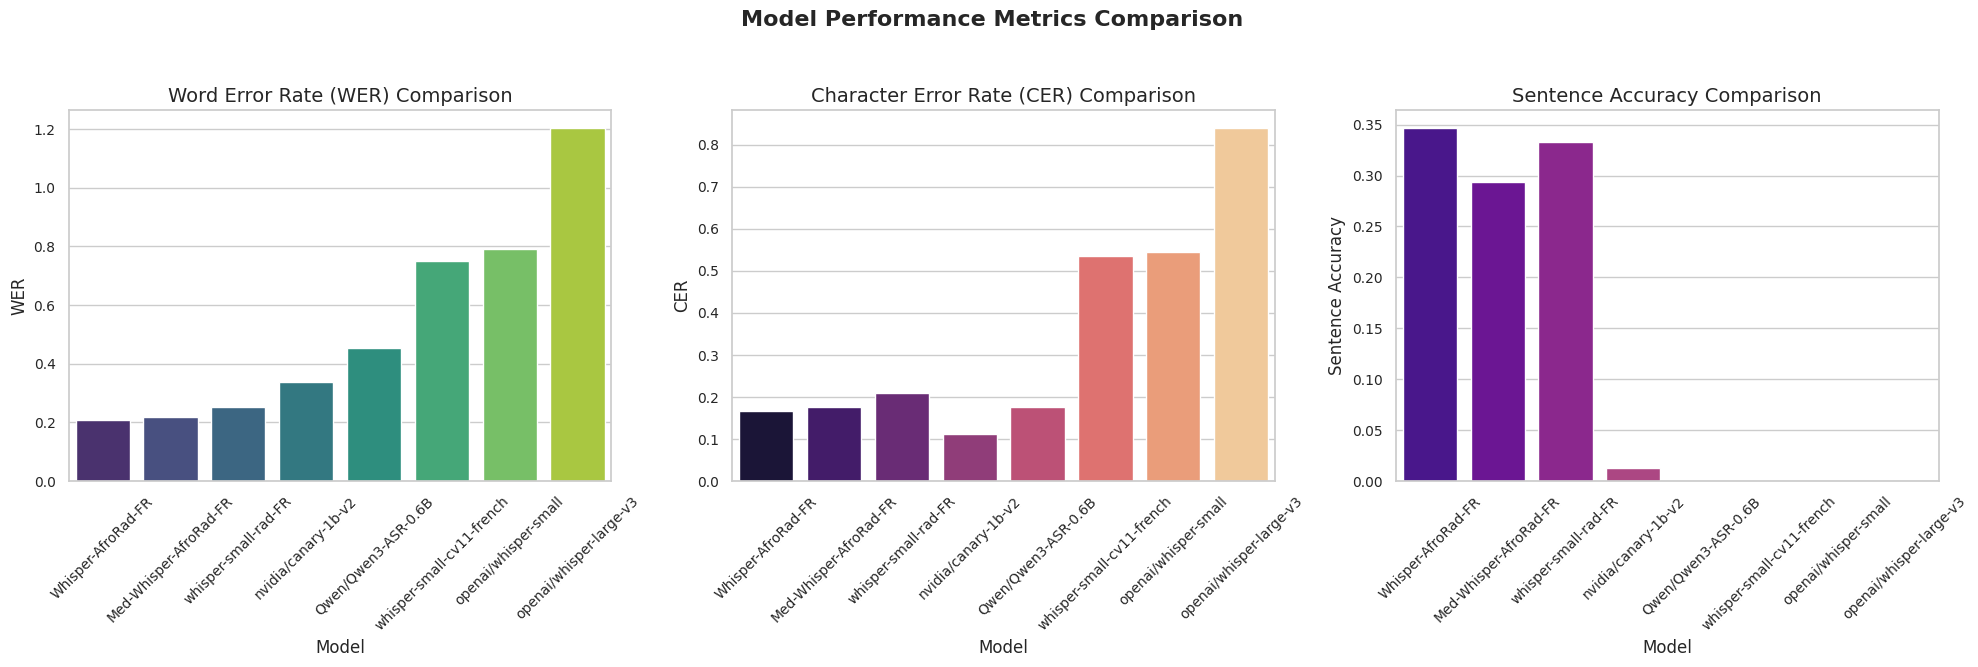

In [35]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set a modern seaborn style and color palette
sns.set_theme(style="whitegrid", palette="viridis")

# Sort the dataframe by WER for better visualization
summary_df_sorted = summary_df.sort_values("WER")

# Plotting
fig, axes = plt.subplots(1, 3, figsize=(20, 7))
plt.suptitle('Model Performance Metrics Comparison', fontsize=16, fontweight='bold')

# WER plot
sns.barplot(x="model", y="WER", data=summary_df_sorted, ax=axes[0], palette="viridis")
axes[0].set_title("Word Error Rate (WER) Comparison", fontsize=14)
axes[0].set_ylabel("WER", fontsize=12)
axes[0].set_xlabel("Model", fontsize=12)
axes[0].tick_params(axis='x', rotation=45, labelsize=10)
axes[0].tick_params(axis='y', labelsize=10)

# CER plot
sns.barplot(x="model", y="CER", data=summary_df_sorted, ax=axes[1], palette="magma")
axes[1].set_title("Character Error Rate (CER) Comparison", fontsize=14)
axes[1].set_ylabel("CER", fontsize=12)
axes[1].set_xlabel("Model", fontsize=12)
axes[1].tick_params(axis='x', rotation=45, labelsize=10)
axes[1].tick_params(axis='y', labelsize=10)

# Full Phrase Accuracy plot
sns.barplot(x="model", y="Sentence Accuracy", data=summary_df_sorted, ax=axes[2], palette="plasma")
axes[2].set_title("Sentence Accuracy Comparison", fontsize=14)
axes[2].set_ylabel("Sentence Accuracy", fontsize=12)
axes[2].set_xlabel("Model", fontsize=12)
axes[2].tick_params(axis='x', rotation=45, labelsize=10)
axes[2].tick_params(axis='y', labelsize=10)

plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to prevent title overlap
plt.show()

In [36]:
def per_file_metrics(all_eval):
    rows = []
    for model_name, df in all_eval.items():
        for _, r in df.iterrows():
            rows.append({
                "audio": Path(r["audio"]).name,
                "model": model_name,
                "wer": wer([r["expectations"]], [r["predictions"]]),
                "cer": cer([r["expectations"]], [r["predictions"]]),
            })
    return pd.DataFrame(rows)

df_perf = per_file_metrics(all_eval)


Heatmap des WER par fichier et modèle

In [37]:
# # Check for duplicates before pivoting
# duplicates = df_perf[df_perf.duplicated(subset=['audio', 'model'], keep=False)]

# if not duplicates.empty:
#     print("Found duplicate entries in df_perf:")
#     display(duplicates.sort_values(by=['audio', 'model']))
#     # Handle duplicates, for example, by taking the mean if appropriate
#     # df_perf_cleaned = df_perf.groupby(['audio', 'model']).mean().reset_index()
#     # pivot = df_perf_cleaned.pivot(index="audio", columns="model", values="wer")
# else:
#     pivot = df_perf.pivot(index="audio", columns="model", values="wer")
#     plt.figure(figsize=(12, 8))
#     sns.heatmap(pivot, cmap="viridis", annot=False)
#     plt.title("WER par fichier et par modèle")
#     plt.xticks(rotation=45)
#     plt.tight_layout()
#     plt.show()

Boxplot des WER par modèle

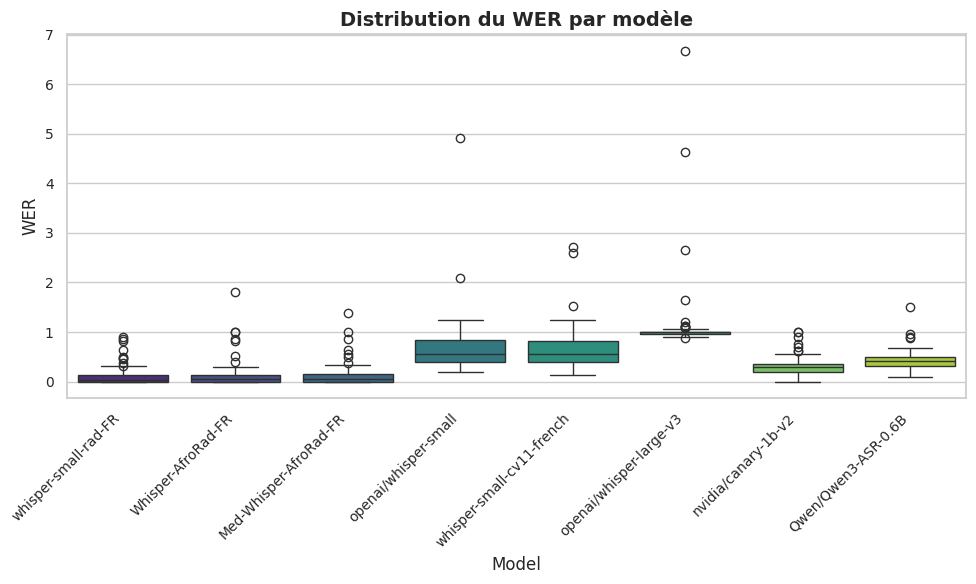

In [38]:
plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid", palette="viridis") # Apply consistent theme
sns.boxplot(x="model", y="wer", data=df_perf, palette="viridis") # Use a color palette
plt.title("Distribution du WER par modèle", fontsize=14, fontweight='bold') # Add a bold title
plt.xlabel("Model", fontsize=12)
plt.ylabel("WER", fontsize=12)
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(fontsize=10)
plt.tight_layout()
plt.show()

### Confiance par token (histogrammes de softmax au décodeur)

In [39]:
# import torch.nn.functional as F

# @torch.no_grad()
# def token_confidences(model_id, ds, processor, forced_ids, sample_rate=16000, device="cuda"):
#     model = WhisperForConditionalGeneration.from_pretrained(model_id).to(device).eval()
#     model.generation_config.forced_decoder_ids = forced_ids
#     conf_all = []
#     for r in ds:
#         wav, sr = torchaudio.load(r["audio"])
#         if wav.dim()==2: wav = wav.mean(dim=0)
#         if sr != sample_rate:
#             wav = torchaudio.functional.resample(wav, sr, sample_rate)
#         inputs = processor(wav.numpy(), sampling_rate=sample_rate, return_tensors="pt").to(device)
#         gen = model.generate(
#             **inputs,
#             # forced_decoder_ids=forced_ids, # Removed this line
#             do_sample=False,
#             temperature=0.0,
#             return_dict_in_generate=True,
#             max_new_tokens=444
#         )
#         seq_ids = gen.sequences  # (1, T)
#         out = model(
#             input_features=inputs.input_features,
#             decoder_input_ids=seq_ids[:, :-1],
#             use_cache=False,
#             output_hidden_states=False,
#             output_attentions=False,
#             return_dict=True
#         )
#         # logits -> proba max par pas
#         # out.logits: [1, T-1, vocab]
#         pmax = F.softmax(out.logits, dim=-1).max(dim=-1).values[0].detach().cpu().numpy()
#         conf_all.append(pmax)  # (T-1,)
#     del model
#     if torch.cuda.is_available(): torch.cuda.empty_cache()
#     # concat variable-length -> histogramme agrégé
#     return np.concatenate(conf_all, axis=0)

# for name, mid in MODELS.items():
#     conf = token_confidences(mid, test_ds, processor, forced_ids, device=DEVICE)
#     plt.figure(figsize=(6,4))
#     plt.hist(conf, bins=30, alpha=.75)
#     plt.title(f"Histogramme des conf. tokens — Décodeur — {name}")
#     plt.xlabel("max softmax prob"); plt.ylabel("Fréquence")
#     plt.show()